In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ast import literal_eval

In [2]:
bd= pd.read_csv('datafixed_bolide_data.csv') #the index for bolide 1 is 12

In [3]:
b2= bd.iloc[38]

In [4]:
b2['duration']

0.057603

In [5]:
lat= literal_eval(b2['lat_stereo_g16'])
long= literal_eval(b2['lon_stereo_g16'])
alt= literal_eval(b2['alt_stereo_g16'])
energy = literal_eval(b2['energyJoules_stereo_g16'])

In [6]:
def findtheta(lat, long, alt):
    x= np.abs(lat[-1]-lat[0])*0.0175
    y= np.abs(long[-1]-long[0])*0.0175
    z= np.abs(alt[-1]-alt[0])*0.0175
    return np.arctan((np.sqrt(x**2+y**2))/z)

def degtom(theta, r=6378137): #r in m
    rad= theta*0.0175
    return r*rad

def airrho(z, H=8500): #calculates density based on rho naught, height, and scale height
                                    #8.5 km is the scale height for Earth and 1.225 kg/m^3 is the density of air at sea level
    return (rho0*(1/(np.e**(z/H))))

H=8500 #meters
rho0= 1.225 #kg/m^3
rockyrho = 3500 #kg/m^3
metalrho = 7500 #kg/m^3 #constants for bolide density based on possible composition
icyrho = 750 #kg/m^3

In [7]:
print (len(lat), len(long), len(alt), len(energy))

27 27 27 27


In [8]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        print(i) #determine the index at which the bolide catastrophically destructs

15


In [9]:
totalmass= 0
totalh= 0 
for i in range (15): 
    deltalat = np.abs(degtom(lat[i+1]-lat[i])) #change in lat converted to meters 
    deltalong = np.abs(degtom(long[i+1]-long[i]))
    deltaalt = (np.abs(alt[i+1]-alt[i]))*1000 #multipled by 1000 to convert to meters
    h= np.sqrt(deltalat**2 + deltalong**2 + deltaalt**2)
    totalh= totalh+h 

    altm = (alt[i]+alt[i+1])*1000
    rho = airrho((1/2)*altm)
    totalmass = totalmass+(h*rho)

In [10]:
rrocky = (3/4)*(totalmass/rockyrho)
rmetal = (3/4)*(totalmass/metalrho)
ricy = (3/4)*(totalmass/icyrho)

print (rrocky, rmetal, ricy) #this unit is METERS 

2.2624137615353163e-06 1.0557930887164809e-06 1.0557930887164807e-05


In [11]:
totalh

38.89377083159722

In [12]:
for i in range(len(alt)-1):
    print (alt[i]-alt[i+1])

-0.0008792900000003101
-0.0008860899999945104
-0.0008861099999961652
-0.0006568800000081865
1.2800000064316919e-06
0.0013340599999907
0.0015587400000072194
0.0013340699999986327
0.0015587299999992865
0.0004238399999962894
-0.00043638999999018324
-0.0008727200000038238
-0.0006451600000048074
-0.0006321099999979651
-0.0008681599999960099
0.00023772999999494004
0.001131619999995337
0.0008916499999997995
0.001127380000014
0.0011302699999902188
0.00045228000000463453
5.790000003003115e-06
1.2029999993501406e-05
-1.0400000007848575e-06
-0.00044932999999502954
-0.0004483000000021775


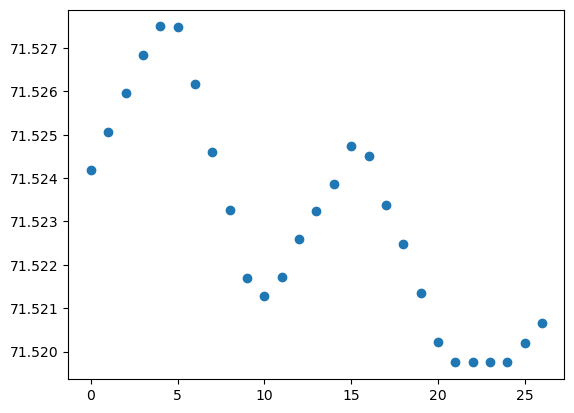

In [13]:
plt.scatter(range(len(alt)), alt)